# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.13.15 | numpy 2.1.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [2]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
    "dtype": str(arr.dtype),
    "shape": arr.shape,
    "ndim": int(arr.ndim),
    "size": int(arr.size),
    "nbytes": int(arr.nbytes),
}

In [3]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [4]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The body below is the broken version. Fix it.
    """
    middle = arr[start:stop].copy()
    middle[:] = 0
    return middle

In [5]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [6]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    std = matrix.std(axis=0)
    return (matrix - matrix.mean(axis=0)) / std

In [7]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [8]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    return {
        "per_column_mean": matrix.mean(axis=0),
        "per_row_sum": matrix.sum(axis=1),
        "per_row_max": matrix.max(axis=1),
        "grand_total": matrix.sum(),
    }

In [9]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [10]:
# Space for the code that supports your answer.
print("_tall.sum():", _tall.sum())
print("shape:", _tall.sum().shape)

print("_tall.sum(axis=0):", _tall.sum(axis=0))
print("shape:", _tall.sum(axis=0).shape)

print("_tall.sum(axis=1):", _tall.sum(axis=1))
print("shape:", _tall.sum(axis=1).shape)

_tall.sum(): -9.792221026356906
shape: ()
_tall.sum(axis=0): [-8.02177989 -0.81004707  8.21145867 -9.17185273]
shape: (4,)
_tall.sum(axis=1): [-0.50510624 -2.09015697  0.15802573  0.22961949 -0.40134908  1.10646439
  2.90490295  1.01447592  1.11822027 -3.48374535  0.81667958  3.52514633
 -1.80920476  1.83156271 -4.02562997 -2.42957279  1.44618058  1.13199867
 -0.61684538  1.78645098  0.75503361  0.57046469 -3.48153912 -0.45100874
 -4.25064576 -0.40944265  2.64439616 -2.02693328 -0.08706021  1.12517462
 -1.78183882  0.36524314  1.32938319 -0.63146496 -5.28006837 -0.28121492
 -1.12785243 -4.68714087  4.05556111  2.49521876  1.05249556  2.00795355
 -1.0681827  -0.16955788  1.22803338 -1.6438678   1.56742297 -0.69945049
 -1.54850182 -1.07094802]
shape: (50,)


**Your answer:**

_tall.sum() returns a single scalar value (-9.7922) because it sums all elements of the array. _tall.sum(axis=0) has shape (4,), so it produces four values because axis 0 collapses the 50 rows and computes one result for each of the four columns. _tall.sum(axis=1) has shape (50,), because axis 1 collapses the four columns and produces one result for each of the 50 rows. To answer “what is the average value of each feature across all samples?”, I would use _tall.mean(axis=0), because the rows represent samples and the columns represent features. Taking the mean along axis 0 therefore gives one average for each of the four features.

## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [11]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.

    Use the mean and standard deviation OF THE SAMPLE itself, not assumed
    values, and NumPy's default ddof=0 for the standard deviation.

    Return a tuple (mask, values):
        mask    a boolean array, the same shape as `sample`, True where the
                value is an outlier
        values  the outlying values themselves, in their original order

    Build the mask with a vectorised comparison; do not loop.
    """
    std = sample.std()

    mask = np.abs(sample - sample.mean()) > k * std
    values = sample[mask]

    return mask, values

In [12]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3100%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [13]:
# Space for the code that supports your answer.
for k in [1, 2, 3, 4, 5]:
    mask, values = sigma_outliers(_normal, k=k)
    print(f"k={k}: {mask.sum()} points flagged")

k=1: 3163 points flagged
k=2: 454 points flagged
k=3: 31 points flagged
k=4: 2 points flagged
k=5: 0 points flagged


**Your answer:**

For k = 1, 3163 points were flagged (31.63%); for k = 2, 454 points (4.54%); for k = 3, 31 points (0.31%); for k = 4, 2 points (0.02%); and for k = 5, no points were flagged. These results are reasonably close to the theoretical normal-distribution rates for k = 1, 2, and 3 (about 32%, 4.6%, and 0.27%). At k = 4 and especially k = 5, a sample of only 10,000 observations is too small to estimate such rare-event rates reliably: the expected numbers are less than one observation at these thresholds. Therefore, using a very large k can make the outlier rule practically unable to detect anything in a sample of this size. A flagged point should not be deleted simply because it is extreme. I would delete one if there were independent evidence of a measurement or recording error, for example if a sensor log showed that the instrument malfunctioned at the exact time the extreme value was recorded.

## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [14]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.

    Equivalent to np.nanmean, but you must implement it with np.isnan and
    boolean masking rather than calling any nan-aware NumPy reduction.

    If every value is missing, return np.nan.
    """
    valid = sample[~np.isnan(sample)]

    if valid.size == 0:
        return np.nan

    return valid.mean()

In [15]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [16]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.

    For each n in `sizes`, draw n values from normal(true_mu, true_sigma)
    using `generator`, and record the sample mean and the UNBIASED sample
    standard deviation (ddof=1).

    Draw the samples in the order the sizes are given, taking every sample
    from the same `generator` object, so that the result is reproducible
    for a given seed.

    Return a dict with three keys, each a NumPy array of len(sizes):
        'n'          the sample sizes, as given
        'mu_hat'     the estimated means
        'sigma_hat'  the estimated standard deviations
    """
    mu_hats = []
    sigma_hats = []

    for n in sizes:
        sample = generator.normal(true_mu, true_sigma, size=n)
        mu_hats.append(sample.mean())
        sigma_hats.append(sample.std(ddof=1))

    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hats),
        "sigma_hat": np.array(sigma_hats),
    }

In [17]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [18]:
# Space for the code that supports your answer.
# (a) Five different seeds, n = 100
print("(a) Five different seeds, n=100")

for seed in [0, 1, 2, 3, 4]:
    result = recover_parameters(
        2.0, 5.0, [100], np.random.default_rng(seed)
    )
    mu = result["mu_hat"][0]
    print(f"seed={seed}: mu_hat={mu:.4f}")


# (b) One fixed seed, n = 100 and n = 10,000
print("\n(b) Fixed seed, different sample sizes")

result = recover_parameters(
    2.0, 5.0, [100, 10_000], np.random.default_rng(0)
)

for n, mu in zip(result["n"], result["mu_hat"]):
    error = abs(mu - 2.0)
    print(f"n={n}: mu_hat={mu:.4f}, error={error:.4f}")

(a) Five different seeds, n=100
seed=0: mu_hat=2.4055
seed=1: mu_hat=1.6319
seed=2: mu_hat=1.9579
seed=3: mu_hat=1.6911
seed=4: mu_hat=1.6835

(b) Fixed seed, different sample sizes
n=100: mu_hat=2.4055, error=0.4055
n=10000: mu_hat=2.0219, error=0.0219


**Your answer:**
With n = 100, the five estimates of mu were 2.4055, 1.6319, 1.9579, 1.6911, and 1.6835 for seeds 0–4. This shows noticeable sampling variation even though the true mean is 2.0. The seed controls the particular sequence of random numbers generated, so changing the seed gives a different random sample. A larger seed does not give a better estimate; it is only a different starting point for the random-number generator. The sample size controls the amount of sampling uncertainty: larger samples generally give more precise estimates. With the fixed seed, the error was 0.4055 at n = 100 and only 0.0219 at n = 10,000. Increasing n by a factor of 100 should reduce the typical error by about sqrt(100) = 10 according to the square-root rule. In this particular experiment the observed error decreased by about 18.5 times, which is possible because individual random samples fluctuate. Re-running with a different seed demonstrates this sampling variability, but it does not reveal a new population parameter. Therefore, an estimate at n = 100 being off by about 0.4 is not necessarily a bug; it can be ordinary sampling variation.

## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [19]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.

    Build the covariance matrix yourself from the three parameters:

        [[ sd_x**2,                      correlation*sd_x*sd_y ],
         [ correlation*sd_x*sd_y,        sd_y**2               ]]

    Draw from it with generator.multivariate_normal.

    Return a tuple (points, covariance):
        points      shape (n, 2)
        covariance  the 2x2 matrix you built, shape (2, 2)
    """

    points = generator.multivariate_normal(
        mean=[0.0, 0.0],
        cov=np.array([
        [sd_x**2, correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y, sd_y**2]
    ]),
        size=n
    )

    return points, np.array([
        [sd_x**2, correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y, sd_y**2]
    ])

In [20]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [21]:
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).

    Both clouds: sd_x = sd_y = 2.0, n = 2000, drawn with `generator`
    via correlated_cloud from Task 8.
    Left panel  correlation 0.0.
    Right panel correlation 0.9.

    Each Axes must have set_xlabel, set_ylabel, set_title and an equal
    aspect ratio. The Figure must have a suptitle.

    Return the Figure and the array of two Axes.
    """
    points_0, _ = correlated_cloud(2.0, 2.0, 0.0, 2000, generator)
    points_9, _ = correlated_cloud(2.0, 2.0, 0.9, 2000, generator)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].scatter(points_0[:, 0], points_0[:, 1], s=10)
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    axes[0].set_title("Correlation = 0.0")
    axes[0].set_aspect("equal")

    axes[1].scatter(points_9[:, 0], points_9[:, 1], s=10)
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].set_title("Correlation = 0.9")
    axes[1].set_aspect("equal")

    fig.suptitle("Comparison of correlations")

    return fig, axes

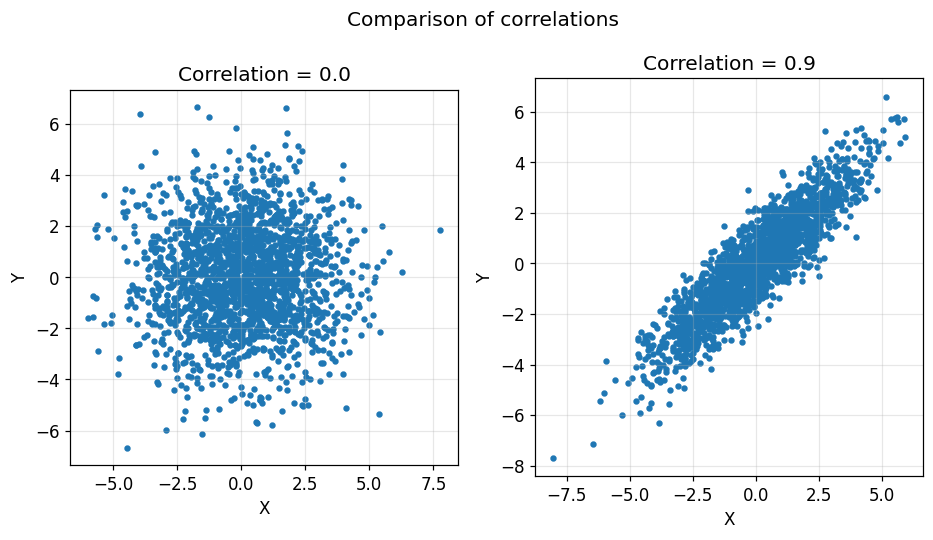

In [22]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()


### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

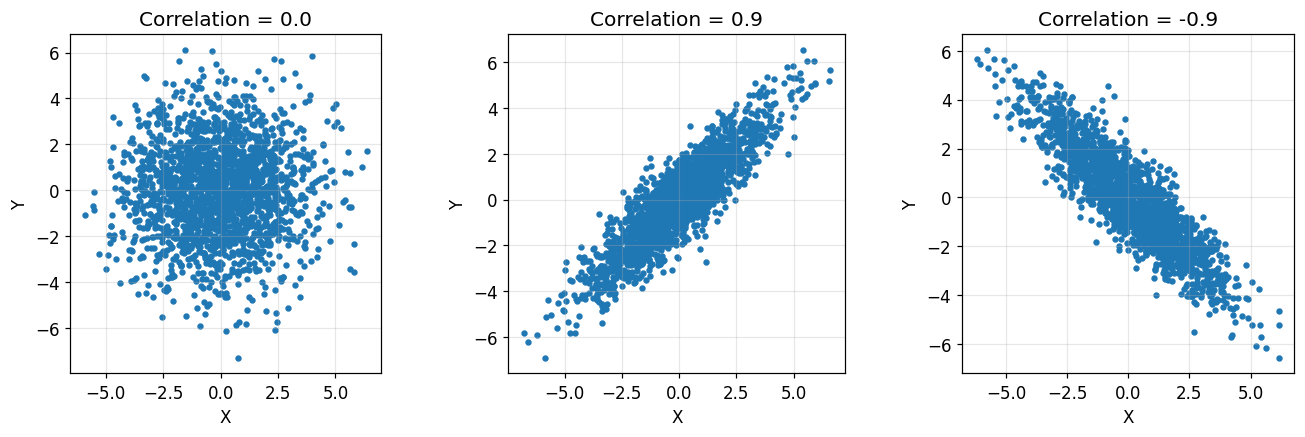

In [23]:
# Space for the code that supports your answer.
gen = np.random.default_rng(42)

points_0, _ = correlated_cloud(2.0, 2.0, 0.0, 2000, gen)
points_pos, _ = correlated_cloud(2.0, 2.0, 0.9, 2000, gen)
points_neg, _ = correlated_cloud(2.0, 2.0, -0.9, 2000, gen)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(points_0[:, 0], points_0[:, 1], s=10)
axes[0].set_title("Correlation = 0.0")

axes[1].scatter(points_pos[:, 0], points_pos[:, 1], s=10)
axes[1].set_title("Correlation = 0.9")

axes[2].scatter(points_neg[:, 0], points_neg[:, 1], s=10)
axes[2].set_title("Correlation = -0.9")

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")

plt.show()

**Your answer:**

Changing the correlation from 0.9 to -0.9 changes the direction of the relationship between x and y. With correlation 0.9, the point cloud slopes upward, while with correlation -0.9 it slopes downward. With correlation 0.0, there is no clear diagonal relationship. However, the spread of x alone and the spread of y alone remain approximately the same in all three cases because their marginal standard deviations have not changed. Therefore, a histogram of only the x coordinate would look approximately the same for correlations 0.0, 0.9, and -0.9, and I would not be able to reliably distinguish the three cases from that histogram alone. This shows that inspecting variables one at a time can hide important relationships between variables.

## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [24]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when it
    is False, because those are different quantities.

    Return (fig, axes).
    """
    fig, axes = plt.subplots(
        1, len(bin_counts),
        figsize=(5 * len(bin_counts), 4),
        squeeze=False
    )

    axes = axes[0]

    for ax, bins in zip(axes, bin_counts):
        ax.hist(sample, bins=bins, density=density)
        ax.set_xlabel("value")
        ax.set_ylabel("density" if density else "count")
        ax.set_title(f"{bins} bins")

    return fig, axes

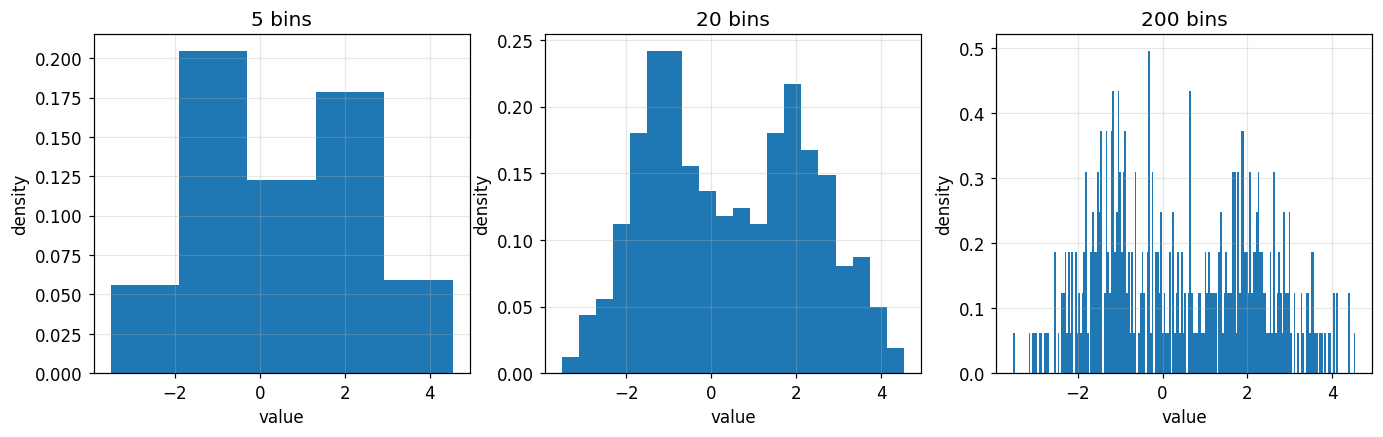

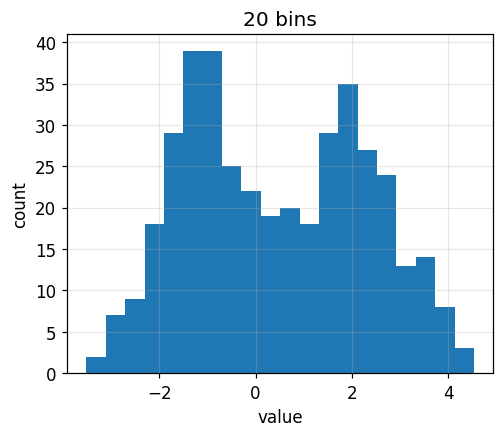

Task 10 passed.


In [25]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

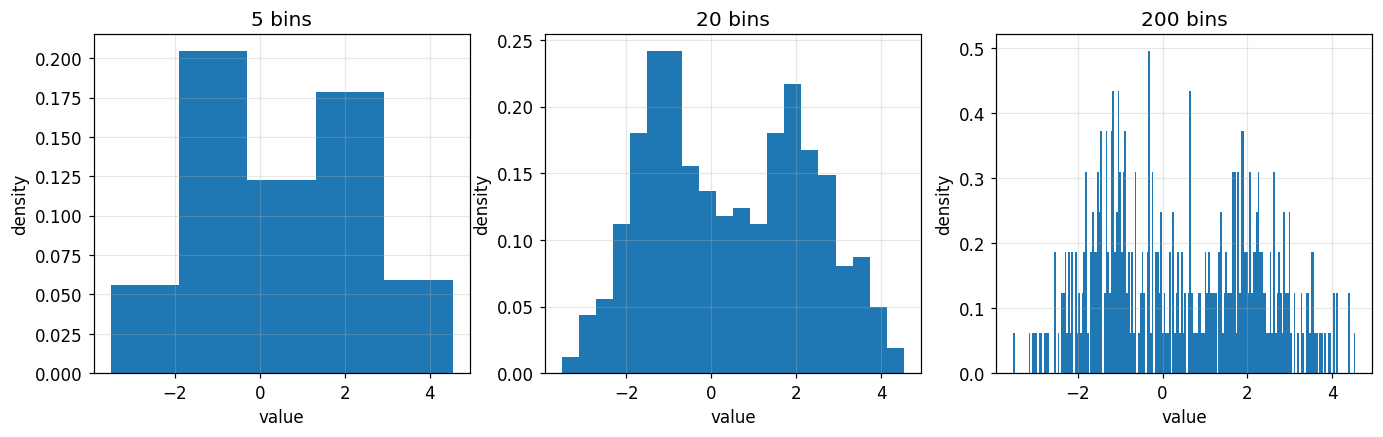

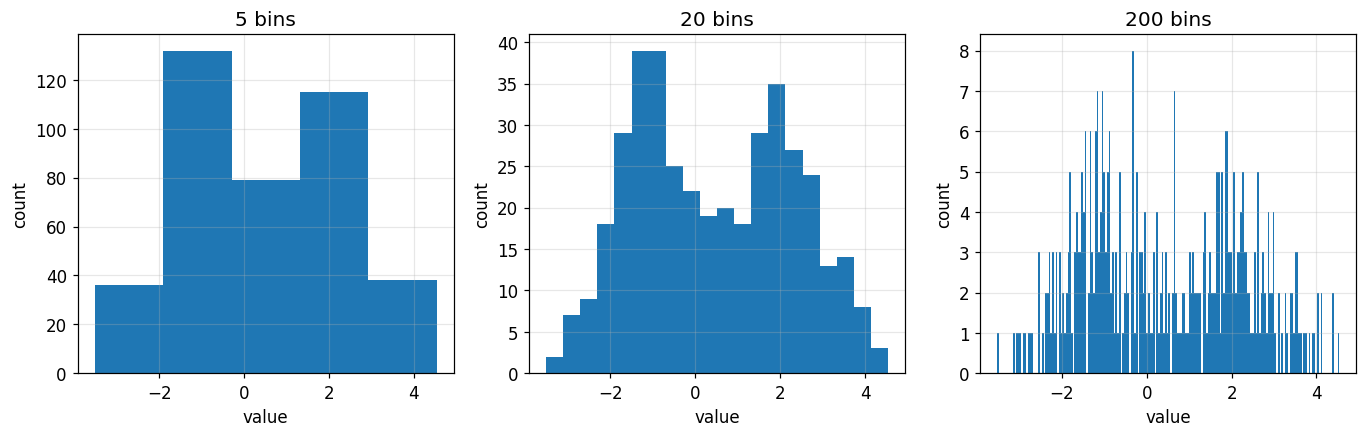

In [26]:
# Space for the code that supports your answer.
# Compare density=True and density=False
fig_density, axes_density = histogram_grid(
    _mixture, [5, 20, 200], density=True
)
plt.show()

fig_count, axes_count = histogram_grid(
    _mixture, [5, 20, 200], density=False
)
plt.show()

**Your answer:**

(a) With 5 bins, the histogram is too coarse and the two-component structure is partly hidden. With 20 bins, the two components are much clearer, with peaks approximately around -1 and +2. With 200 bins, the histogram becomes very noisy because there are too few observations in each bin. The many narrow peaks at 200 bins should not be interpreted as real features of the population; most of them are sampling noise caused by using bins that are too narrow.

(b) The density=True and density=False histograms have the same overall shape, but their y-axis scales are different. With density=False, the height of each bar is the raw number of observations in that bin. With density=True, the counts are normalized by the total number of observations and the bin width, so that the total area under the histogram is 1. This makes distributions from samples of different sizes comparable because the vertical scale represents density rather than raw counts.

(c) If a colleague showed me a histogram with a clear double peak, my first question would be: “What bin width or number of bins did you use, and does the double peak remain when you try other reasonable bin widths?” A double peak in one histogram alone is not sufficient evidence that the population really contains two subgroups.

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [27]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


In [28]:
# Your analysis. Add as many cells as you need.
description = describe_array(mystery_sample)

print("Array description:")
print(description)

print("\nStatistics:")
print("Mean:", mystery_sample.mean())
print("Median:", np.median(mystery_sample))
print("Standard deviation:", mystery_sample.std())
print("Minimum:", mystery_sample.min())
print("Maximum:", mystery_sample.max())

Array description:
{'dtype': 'float64', 'shape': (5000,), 'ndim': 1, 'size': 5000, 'nbytes': 40000}

Statistics:
Mean: 10.631054523018596
Median: 10.09249144940759
Standard deviation: 5.065035346894628
Minimum: 2.571604519822613
Maximum: 59.72793153394517


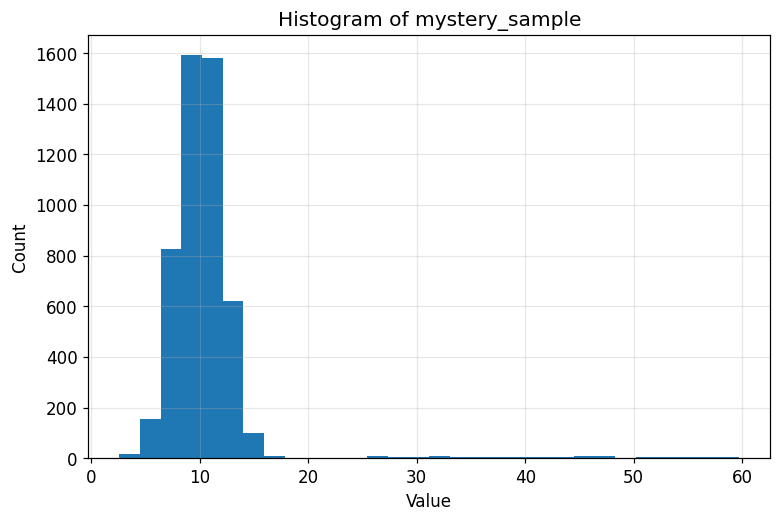

In [29]:
# 3. Histogram of the sample

plt.figure(figsize=(8, 5))

plt.hist(mystery_sample, bins=30)

plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Histogram of mystery_sample")

plt.show()

In [30]:
# 4. Apply the k-sigma rule with k = 3

mask, flagged_values = sigma_outliers(mystery_sample, k=3.0)

print("Number of flagged points:", mask.sum())
print("Percentage flagged:", mask.mean() * 100)
print("Flagged values:", flagged_values)

Number of flagged points: 94
Percentage flagged: 1.8800000000000001
Flagged values: [28.38870136 58.50487283 28.41010552 36.0829553  43.91977211 37.04098496
 44.21107861 43.21547764 40.94667322 27.55323518 26.71658896 30.95221192
 31.24023667 54.6524416  46.12028996 41.1389446  51.05606085 56.18115548
 58.0054039  53.71631602 50.24001562 32.41047708 47.44514607 55.46716416
 46.4894671  41.33452273 30.93072598 55.45214891 40.51701557 53.45745626
 53.44102081 33.45464972 32.36418233 27.69033213 46.06325237 47.54463317
 47.85413235 51.15644507 33.52710365 55.78196002 26.67535804 41.2572299
 50.50967539 30.10021607 46.03310118 31.86165371 54.4569901  27.79517064
 44.66009976 59.30114071 38.40071394 45.97022201 59.45281475 39.81633052
 45.92739992 50.1536725  44.84724289 59.72793153 47.04327807 52.73398297
 27.09686285 30.96575255 49.57611704 47.53037681 54.14455726 29.61068721
 33.48316345 53.84438646 48.00175288 41.73960924 53.62253353 36.07873578
 31.91491369 34.09289119 33.01880505 34.5

In [31]:
# 5. Compare statistics before and after removing flagged points

clean_sample = mystery_sample[~mask]

print("BEFORE removing flagged points:")
print("Mean:", mystery_sample.mean())
print("Standard deviation:", mystery_sample.std())

print("\nAFTER removing flagged points:")
print("Mean:", clean_sample.mean())
print("Standard deviation:", clean_sample.std())

print("\nOriginal sample size:", mystery_sample.size)
print("Clean sample size:", clean_sample.size)
print("Removed points:", mask.sum())

BEFORE removing flagged points:
Mean: 10.631054523018596
Standard deviation: 5.065035346894628

AFTER removing flagged points:
Mean: 10.020966697993872
Standard deviation: 2.0930020976036245

Original sample size: 5000
Clean sample size: 4906
Removed points: 94


**Your write-up:**
The mystery_sample is a one-dimensional NumPy array with shape (5000,), dtype float64, and 5000 elements. It occupies 40,000 bytes of memory. The original sample has a mean of approximately 10.6311, a median of 10.0925, and a standard deviation of 5.0650. The minimum is 2.5716 and the maximum is 59.7279. The mean being higher than the median suggests that the distribution is right-skewed or contains unusually large values even before plotting the data.

I plotted the sample using a histogram with 30 bins. I chose 30 bins because it provides enough detail to show the overall shape and the extreme values without making the histogram excessively noisy. The histogram shows that most observations are concentrated around approximately 5–17, while a small number of observations extend much farther to the right, approximately between 25 and 60.

Applying the k-sigma rule with k = 3 flagged 94 of the 5000 observations, which is 1.88% of the sample. For normally distributed data, approximately 0.27% would be expected outside three standard deviations, corresponding to only about 13–14 observations in a sample of 5000. Therefore, this sample contains substantially more extreme observations than would be expected from a normal distribution.

Before removing the flagged observations, the mean was 10.6311 and the standard deviation was 5.0650. After excluding the 94 flagged observations, the mean decreased to 10.0210 and the standard deviation decreased to 2.0930. This shows that the extreme observations have a substantial effect on the sample statistics.

However, the flagged observations should not automatically be deleted simply because they satisfy the 3-sigma rule. Before deciding whether to remove them, I would need information about how the measurements were collected and whether these extreme values could represent valid observations. For example, I would check for measurement or sensor errors, data-entry errors, calibration problems, or values recorded under different experimental conditions. If there were independent evidence that the extreme observations resulted from such errors, removing them could be justified. If they are genuine measurements produced by the process being studied, they should generally be retained and the distribution should instead be analysed in a way that accounts for its non-normal structure.

## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.